# Events Storytelling 

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

BLUE = "#1E88E5"    
GREEN = "#43A047"     
RED = "#E53935"     
ORANGE = "#FB8C00"    
PURPLE = "#8E24AA"    
TEAL = "#00897B"       
YELLOW = "#FDD835"     
PINK = "#D81B60"      
GRAY_1= "#EAEAEA"  
GRAY_2 = "#B0BEC5"   
GRAY_3 = "#37474F" 
BAKGRUND = "#FFFFFF"
KORALL = "#FF6666"  



In [16]:
df= pd.read_csv("api/data/events_combined.csv")

df.head()

,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,...,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour,source
0,Z698xZq2Z1k-Fudb3,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-14,18:00,onsale,Miscellaneous,Food & Drink,Restaurant,...,Stockholm,Södermannagatan 27,59.31209,18.08133,Tuesday,April,4,2026,18.0,ticketmaster
1,Z698xZq2Z1k37ef-A,Eric Idle,https://www.ticketmaster.se/event/eric-idle-al...,https://s1.ticketm.net/dam/e/d88/0cbf49c5-f18e...,2026-04-14,19:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Tuesday,April,4,2026,19.0,ticketmaster
2,Z698xZq2Z16vZ0G9_M,40 Fingers,https://www.ticketmaster.se/event/40-fingers-b...,https://s1.ticketm.net/dam/e/a38/c01c9483-250c...,2026-04-15,19:30,onsale,Music,Rock,Pop,...,Stockholm,Götgatan 55,59.31378,18.07384,Wednesday,April,4,2026,19.0,ticketmaster
3,Z698xZq2Z16vavQaZx,Amanda Bergman,https://www.ticketmaster.se/event/amanda-bergm...,https://s1.ticketm.net/dam/a/da1/c489a12c-bab8...,2026-04-15,19:30,onsale,Music,Alternative,Indie Pop,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Wednesday,April,4,2026,19.0,ticketmaster
4,Z698xZq2Z16va-0gjy,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-16,18:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Södermannagatan 27,59.31209,18.08133,Thursday,April,4,2026,18.0,ticketmaster


# Event Distribution by Segment (Top 3 Highlighted)

# “Which segments dominate Stockholm?”

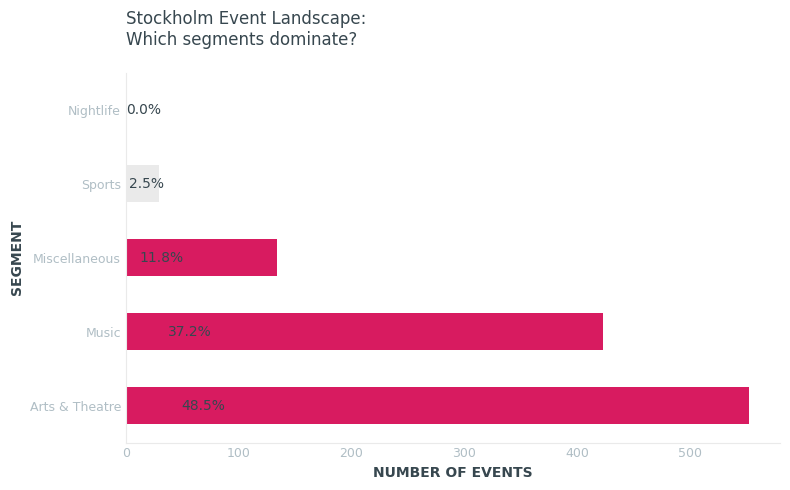

In [58]:
df_segment = df.groupby("segment")["event_id"].count().sort_values()

total = df_segment.sum()
df_pct = df_segment / total * 100

colors = [GRAY_1] * len(df_segment)
colors[-1] = PINK  # highlight top segment
colors[-2] = PINK
colors[-3] = PINK

ax = df_segment.plot(kind="barh", figsize=(8,5), color=colors)

ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color(GRAY_1)

ax.tick_params(axis="both", colors=GRAY_2, labelsize=9, length=0)
ax.set_xlabel("NUMBER OF EVENTS", color=GRAY_3, fontweight="bold")
ax.set_ylabel("SEGMENT", color=GRAY_3, fontweight="bold")

# percentage labels
for i, v in enumerate(df_pct):
    ax.text(v + 0.5, i, f"{v:.1f}%", color=GRAY_3, va="center")


ax.set_title(
    "Stockholm Event Landscape:\nWhich segments dominate?",
    loc="left", color=GRAY_3, pad=20
)

ax.invert_yaxis()

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("output/segment_distribution.png", dpi=150)

# Events by Hour , “When is peak demand?”

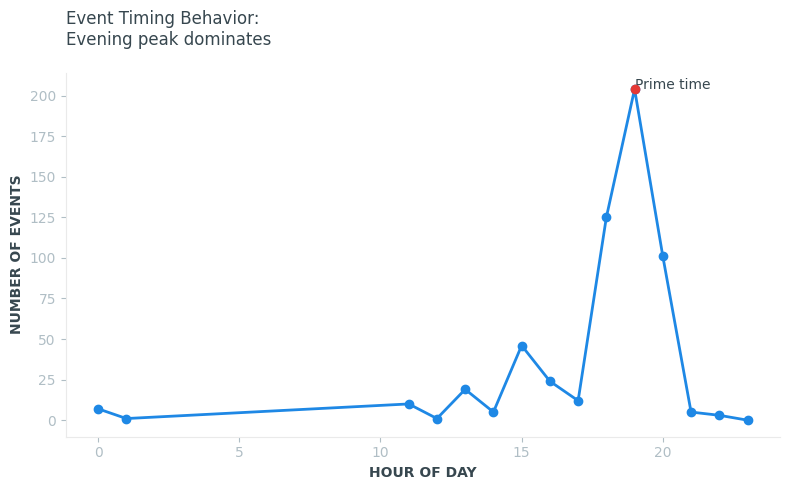

In [51]:
df_hour = df.groupby("hour")["event_id"].count()

ax = df_hour.plot(kind="line", figsize=(8,5), linewidth=2, color=BLUE, marker= "o")

ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color(GRAY_1)

ax.tick_params(axis="both", colors=GRAY_2)

ax.set_xlabel("HOUR OF DAY", color=GRAY_3, fontweight="bold")
ax.set_ylabel("NUMBER OF EVENTS", color=GRAY_3, fontweight="bold")

ax.set_title(
    "Event Timing Behavior:\nEvening peak dominates",
    loc="left", color=GRAY_3, pad=20
)

peak_hour = df_hour.idxmax()
peak_value = df_hour.max()

ax.scatter(peak_hour, peak_value, color=RED, zorder=5)

ax.annotate(xy=(19, df_hour.max()), text="Prime time", color=GRAY_3)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("output/events_by_hour.png", dpi=150)

# Top Venues (Market Concentration), “Which venues control the event market?”

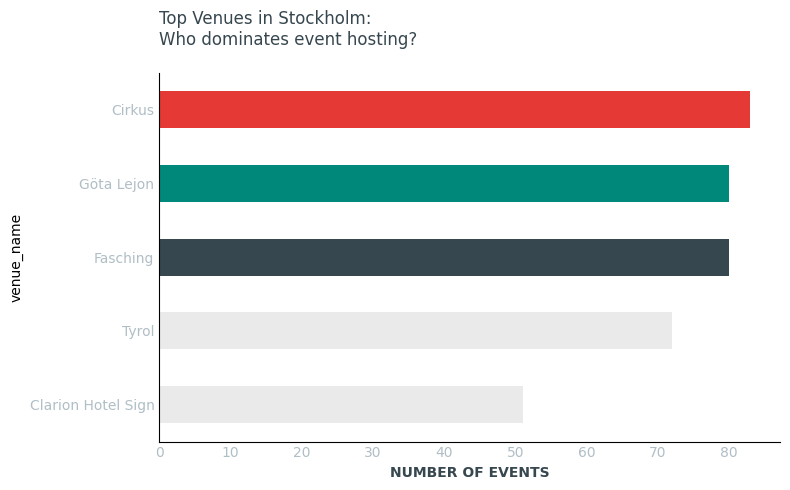

In [59]:
df_venue = df["venue_name"].value_counts().head(5)

colors = [GRAY_1]*len(df_venue)
colors[0] = RED
colors[1] = TEAL
colors[2] = GRAY_3

ax = df_venue.plot(kind="barh", figsize=(8,5), color=colors)

ax.spines[["top","right"]].set_visible(False)
ax.tick_params(axis="both", colors=GRAY_2, length=0)

ax.set_xlabel("NUMBER OF EVENTS", color=GRAY_3, fontweight="bold")

ax.set_title(
    "Top Venues in Stockholm:\nWho dominates event hosting?",
    loc="left", color=GRAY_3, pad=20
)

ax.invert_yaxis()

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("output/top_venues.png", dpi=150)

# Events by Day of Week (Demand Pattern) “What day of the week should we schedule more events?”

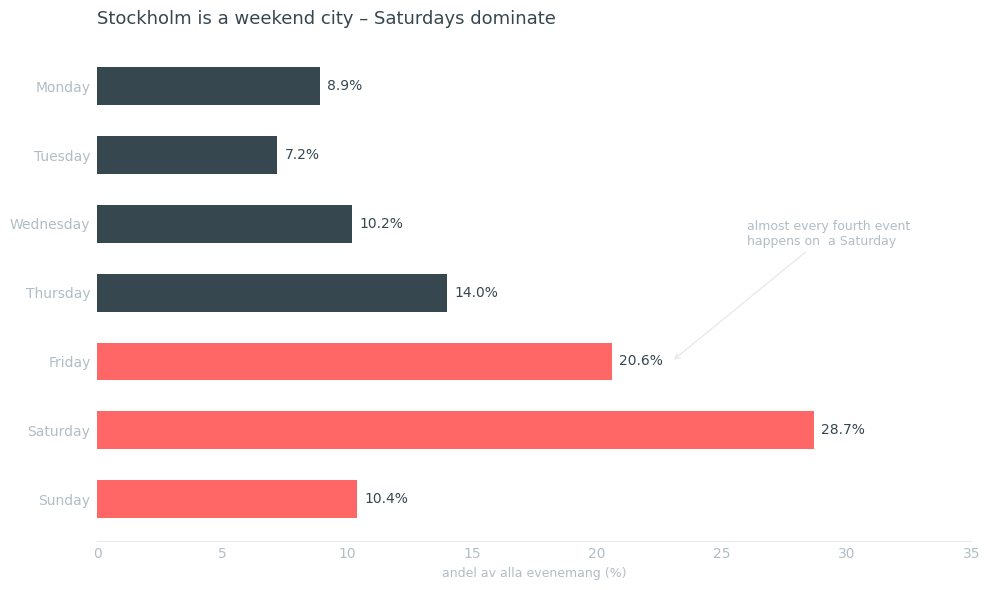

In [62]:

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_counts = df['day_of_week'].value_counts().reindex(day_order).fillna(0)
total = day_counts.sum()
pct = (day_counts / total * 100).round(1)

colors = [KORALL if day in ['Friday', 'Saturday', 'Sunday'] else GRAY_3 for day in day_order]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BAKGRUND)
ax.set_facecolor(BAKGRUND)

bars = ax.barh(day_labels[::-1], pct.values[::-1], color=colors[::-1], height=0.55, edgecolor='none')

for bar, val in zip(bars, pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', ha='left', color=GRAY_3, fontsize=10)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRAY_1)
ax.tick_params(colors=GRAY_2, labelsize=10, length=0, pad=5)
ax.set_xlabel('andel av alla evenemang (%)', color=GRAY_2, fontsize=9)
ax.set_ylabel('')
ax.set_xlim(0, 35)

ax.set_title(
    'Stockholm is a weekend city – Saturdays dominate',
    loc='left',
    color=GRAY_3,
    fontsize=13,
    pad=15
)

# saturday stands out 
ax.annotate(
    xy=(23, 2),
    text='almost every fourth event\nhappens on  a Saturday',
    color=GRAY_2,
    fontsize=9,
    xytext=(26, 3.7),
    arrowprops=dict(arrowstyle='->', color=GRAY_1, lw=1)
)

fig.tight_layout()
fig.savefig('output/events_by_day.png', dpi=250, bbox_inches='tight', facecolor=BAKGRUND)

# Genre Share (Pie Chart) ,“What kind of experiences are people getting?”

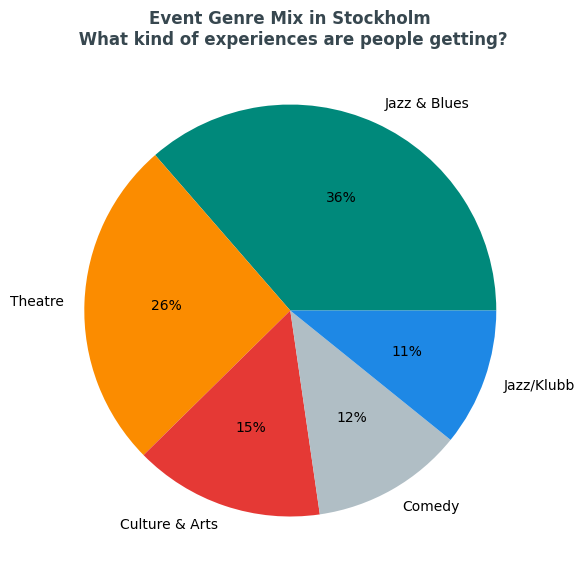

In [73]:
df_genre = df["genre"].value_counts().head()

fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    df_genre,
    labels=df_genre.index,
    autopct="%1.0f%%",
    colors=[TEAL,ORANGE,  RED, GRAY_2, BLUE, ]
)

ax.set_title(
    "Event Genre Mix in Stockholm\n What kind of experiences are people getting?",
    color=GRAY_3, fontweight="bold"
)

fig.tight_layout()
fig.savefig("output/genre_share.png", dpi=150)